## Notebook map

This notebook contains different models used to estimate **sales data predictions.**

**The input used in the model is as follows:**
1. Training dataset (sales.csv) of ~64,000 labeled entries containing store and day-level information
2. Test set (REAL_DATA.csv) of ~70,000 entries without sales figures.


**Key outcomes of this exercise:**

The expected output is the test dataset with a predicted "sales" column addeda along with the model evaluation:
1. "Real'life data set" with anextra column called "sales", with the predicitons (in .csv)
2. An expected value of R2 of performance in the model

**Authors:**
1. Benay
2. Soledad
3. Marcelo


____________________________________________________________________________________________________________

## 0. EDA

### 0.1 Data Cleaning

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# ── 1. Imports ────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler


In [6]:
# ── 2. Load the Data ──────────────────────────────────────────────────────────
train = pd.read_csv('/content/drive/MyDrive/data/sales.csv')
test = pd.read_csv('/content/drive/MyDrive/data/REAL_DATA.csv')

In [7]:
train.head(5)

,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,425390,366,4,2013-04-18,517,1,0,0,0,4422
1,291687,394,6,2015-04-11,694,1,0,0,0,8297
2,411278,807,4,2013-08-29,970,1,1,0,0,9729
3,664714,802,2,2013-05-28,473,1,1,0,0,6513
4,540835,726,4,2013-10-10,1068,1,1,0,0,10882


In [8]:
# ── 3. Data Cleaning ──────────────────────────────────────────────────────────

# Remove rows where the store was closed
# When open = 0, sales is always 0 which will confuse the model
train = train[train['open'] == 1]

# state_holiday has letters instead of numbers, we need to fix that
train['state_holiday'] = train['state_holiday'].replace({'a': 1, 'b': 1, 'c': 1})
train['state_holiday'] = pd.to_numeric(train['state_holiday'])

test['state_holiday'] = test['state_holiday'].replace({'a': 1, 'b': 1, 'c': 1})
test['state_holiday'] = pd.to_numeric(test['state_holiday'])

# Extract useful info from the "date" column
train['date'] = pd.to_datetime(train['date'], dayfirst=True)
train['month'] = train['date'].dt.month
train['year'] = train['date'].dt.year
train['day'] = train['date'].dt.day

test['date'] = pd.to_datetime(test['date'], dayfirst=True)
test['month'] = test['date'].dt.month
test['year'] = test['date'].dt.year
test['day'] = test['date'].dt.day

#Drop the column date to avoid reduncancies in variables
train = train.drop(columns=['date', 'store_ID'])
test = test.drop(columns=['date', 'store_ID'])

#Check if the Data has N.a. or blanks
print(train.isna().sum())

/tmp/ipykernel_6922/454861843.py:15: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  train['date'] = pd.to_datetime(train['date'], dayfirst=True)


Unnamed: 0             0
day_of_week            0
nb_customers_on_day    0
open                   0
promotion              0
state_holiday          0
school_holiday         0
sales                  0
month                  0
year                   0
day                    0
dtype: int64


### 0.2 Prepare Features and Target

In [9]:
#Sorting out data by time
train = train.sort_values(['year', 'month', 'day'])
train.head(-5)

,Unnamed: 0,day_of_week,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales,month,year,day
124688,580156,2,777,1,0,1,1,3821,1,2013,1
147155,277247,2,729,1,0,1,1,3102,1,2013,1
222078,253110,2,1751,1,0,1,1,9643,1,2013,1
225395,239216,2,1444,1,0,1,1,6851,1,2013,1
312202,60765,2,1248,1,0,1,1,5035,1,2013,1
...,...,...,...,...,...,...,...,...,...,...,...
633566,561792,5,904,1,1,0,1,8970,7,2015,31
633781,515455,5,835,1,1,0,1,8554,7,2015,31
635782,441172,5,906,1,1,0,0,13911,7,2015,31
636683,534705,5,884,1,1,0,1,10050,7,2015,31


In [10]:
# These are the columns we will use to predict sales
features = ['day_of_week', 'nb_customers_on_day', 'promotion',
            'state_holiday', 'school_holiday', 'month', 'year', 'day']

#We create two variables X: (1) The original (2) The same vatiable X but with the column "nb_customers_on_day" escaled

X = train[features]

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled['nb_customers_on_day'] = scaler.fit_transform(X[['nb_customers_on_day']])

y = train['sales']

# This is what we want to predict in the end
X_real = test[features]

In [11]:
# Split the training data into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_scaled, X_val_scaled, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print('Training rows:', X_train.shape[0])
print('Validation rows:', X_val.shape[0])


Training rows: 425612
Validation rows: 106404


### 0.3 Data Visualization

In [12]:
#sns.pairplot(X)

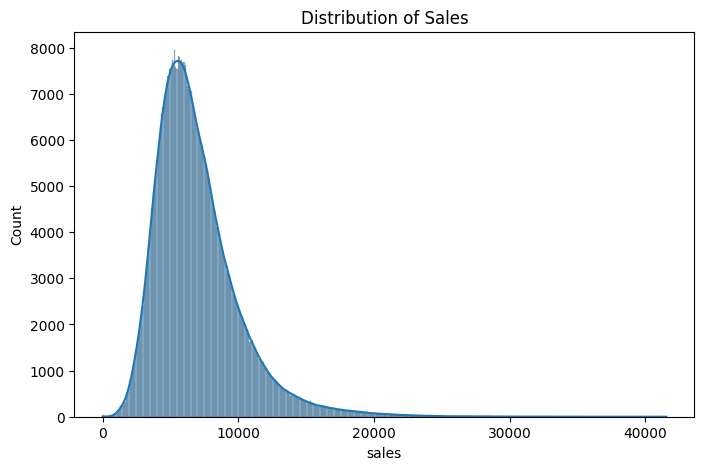

Skewness: 1.5968170021351182


In [13]:
plt.figure(figsize=(8,5))
sns.histplot(train.sales, kde=True)
plt.title("Distribution of Sales")
plt.show()

print("Skewness:", train.sales.skew())

The distribution of the target variable sales is right-skewed, with a skewness of 1.60.
This indicates that most sales values are concentrated in the lower range, while a smaller number of observations have very high sales values.
This skewness suggests the presence of extreme values and may affect models that assume normality, such as Linear Regression.

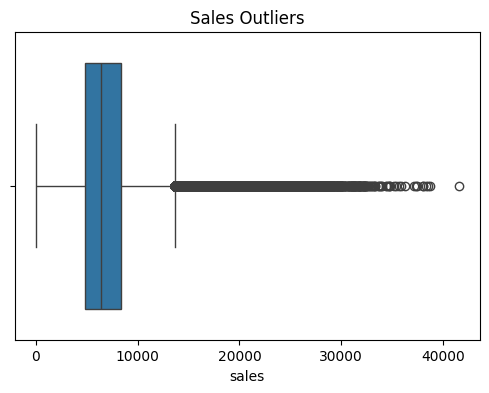

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(x=train.sales)
plt.title("Sales Outliers")
plt.show()

The boxplot confirms the presence of significant outliers in the sales data, with some values reaching above 40,000.
These extreme values may influence model performance, especially for distance-based models like KNN and linear models.
Tree-based models such as Decision Tree and Random Forest are expected to handle these outliers better.

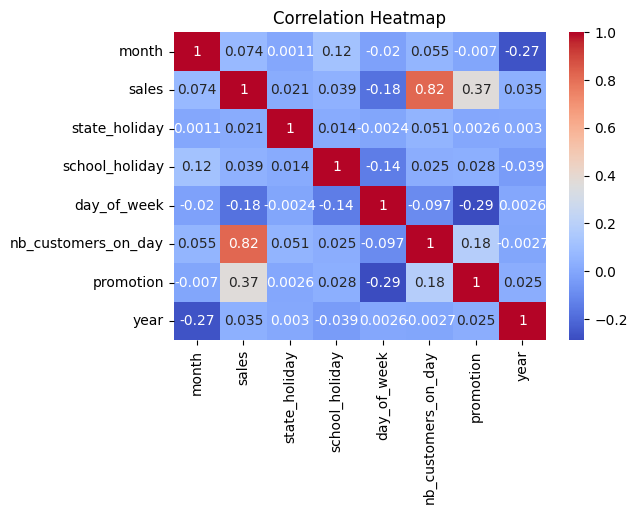

In [15]:
cols = [train.month, train.sales, train.state_holiday, train.school_holiday, train.day_of_week, train.nb_customers_on_day, train.promotion, train.year]

plt.figure(figsize=(6,4))
sns.heatmap(pd.DataFrame(cols).T.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

The presence of skewness and outliers suggests that non-linear models, such as Decision Tree and Random Forest, may perform better than linear models.

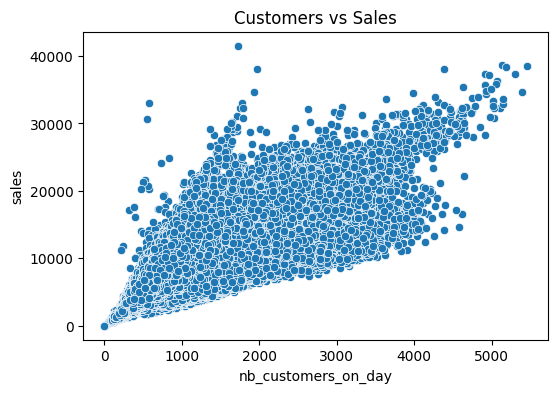

In [16]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=train.nb_customers_on_day, y=train.sales)
plt.title("Customers vs Sales")
plt.show()

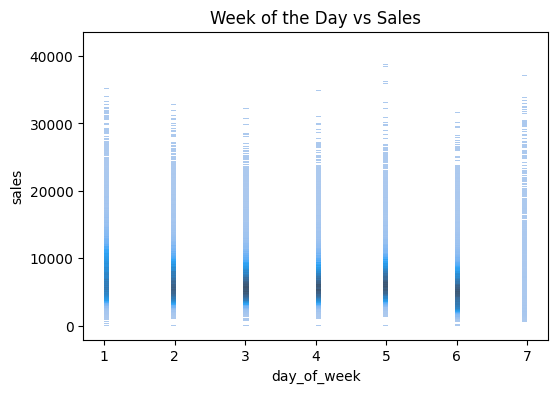

In [17]:
plt.figure(figsize=(6,4))
sns.histplot(x=train.day_of_week, y=train.sales)
plt.title("Week of the Day vs Sales")
plt.show()

In [18]:
print(train.groupby(train.state_holiday)['sales'].mean())
print(train.groupby(train.state_holiday)['nb_customers_on_day'].mean())
print(train.groupby(train.school_holiday)['sales'].mean())
print(train.groupby(train.school_holiday)['nb_customers_on_day'].mean())

state_holiday
0    6957.122912
1    8913.146805
Name: sales, dtype: float64
state_holiday
0     762.286286
1    1381.704663
Name: nb_customers_on_day, dtype: float64
school_holiday
0    6900.529802
1    7204.427408
Name: sales, dtype: float64
school_holiday
0    758.055643
1    783.438790
Name: nb_customers_on_day, dtype: float64


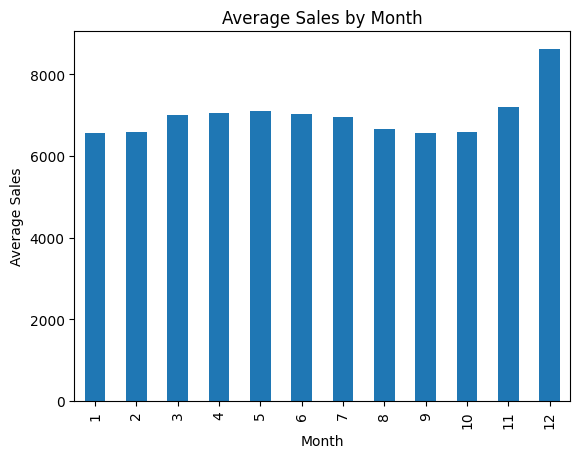

In [19]:
monthly_sales = train.groupby("month")["sales"].mean()
monthly_sales.plot(kind="bar")
plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.show()

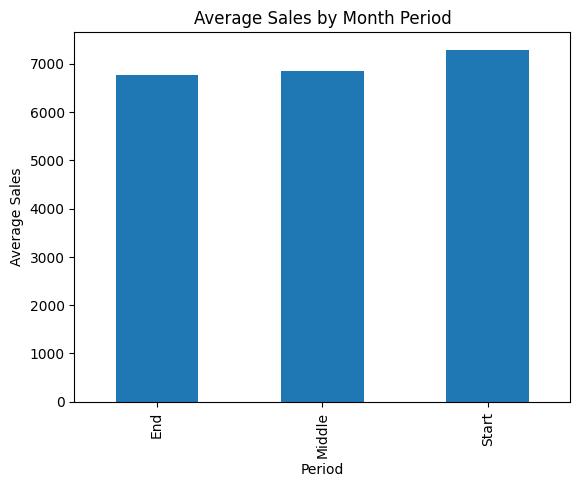

In [20]:
def day_group(d):
    if d <= 10:
        return "Start"
    elif d <= 20:
        return "Middle"
    else:
        return "End"
train["day_group"] = train["day"].apply(day_group)
grouped_days = train.groupby("day_group")["sales"].mean()
grouped_days.plot(kind="bar")
plt.title("Average Sales by Month Period")
plt.xlabel("Period")
plt.ylabel("Average Sales")
plt.show()

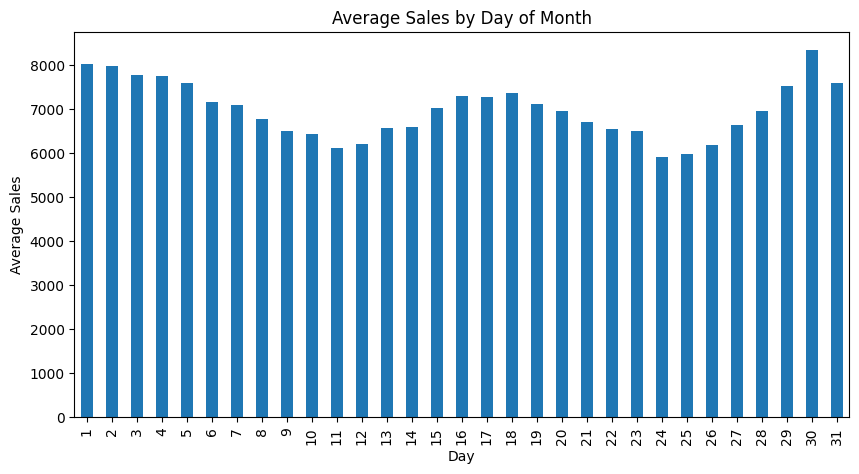

In [21]:
daily_sales_month = train.groupby("day")["sales"].mean()
plt.figure(figsize=(10,5))
daily_sales_month.plot(kind="bar")
plt.title("Average Sales by Day of Month")
plt.xlabel("Day")
plt.ylabel("Average Sales")
plt.show()

### Key Conclusion:

- Additionally, holiday variables are sparse (low frequency), which reduces their correlation values.
Further analysis using grouped statistics and visualizations revealed that holidays and seasonal patterns do have an impact on sales, even though this is not captured by simple correlation.
- State holidays strongly increase both customers and sales, while school holidays have only a minor effect.
This confirms that customer volume is the main driver of sales, with holidays influencing sales indirectly through customer traffic.
- Sales show a clear seasonal pattern across the year.
They gradually increase from the beginning of the year, remain relatively stable in the middle months, and reach their highest levels in November and December. December has the highest average sales, indicating strong end-of-year demand, likely driven by holidays and increased customer activity.
- Sales are highest at the beginning and end of the month and lowest in the middle, indicating a cyclical monthly pattern in customer behavior.
- Day-of-week analysis shows that sales vary significantly across the week. The highest sales occur on Day 7 and Day 1, while the lowest sales are observed on Day 6. This indicates strong weekly patterns, likely reflecting differences in customer activity between weekdays and weekends.



In [22]:
# Overview of Train Data ────────────────────────────────────────────
train.head()
train.shape
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 532016 entries, 124688 to 640796
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   Unnamed: 0           532016 non-null  int64 
 1   day_of_week          532016 non-null  int64 
 2   nb_customers_on_day  532016 non-null  int64 
 3   open                 532016 non-null  int64 
 4   promotion            532016 non-null  int64 
 5   state_holiday        532016 non-null  int64 
 6   school_holiday       532016 non-null  int64 
 7   sales                532016 non-null  int64 
 8   month                532016 non-null  int32 
 9   year                 532016 non-null  int32 
 10  day                  532016 non-null  int32 
 11  day_group            532016 non-null  object
dtypes: int32(3), int64(8), object(1)
memory usage: 62.8+ MB


In [23]:
# Overview of Test Data ────────────────────────────────────────────
test.head()
test.shape
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71205 entries, 0 to 71204
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   index                71205 non-null  int64
 1   day_of_week          71205 non-null  int64
 2   nb_customers_on_day  71205 non-null  int64
 3   open                 71205 non-null  int64
 4   promotion            71205 non-null  int64
 5   state_holiday        71205 non-null  int64
 6   school_holiday       71205 non-null  int64
 7   month                71205 non-null  int32
 8   year                 71205 non-null  int32
 9   day                  71205 non-null  int32
dtypes: int32(3), int64(7)
memory usage: 4.6 MB



____________________________________________________________________________________________________________

## 1. Supervised Models

We will first assess supervised regressors:

1. **K-Nearest Neighbours**
2. **Linear Regression**  
   2.1. OLS Regression   
   2.2. OLS Regression applying L2 and L1 regularization  
4. **Decision Treee**
5. **Random Forest**

### 1.1 KNN (K-Nearest Neighbours)

In [25]:
#We tried various parameters - srhotlisted the ones delivering ones delivering better results for easiness of computation

for k in [5, 10, 25]:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_train_pred = knn.predict(X_train) #prediction on training data
    y_val_pred = knn.predict(X_val) #prediction on val data
    MSE_knn = mean_squared_error(y_val, y_val_pred)

    train_r2_knn = r2_score(y_train, y_train_pred)
    val_r2_knn  = r2_score(y_val, y_val_pred)

    print(f"k={k:>3d}  |  Train R2: {train_r2_knn:.2%}  |  Test (val) R2: {val_r2_knn:.2%}, MSE: {MSE_knn:.0f}")

k=  5  |  Train R2: 81.93%  |  Test (val) R2: 72.87%, MSE: 2624312
k= 10  |  Train R2: 79.06%  |  Test (val) R2: 74.45%, MSE: 2471606
k= 25  |  Train R2: 76.71%  |  Test (val) R2: 74.79%, MSE: 2438339


In [ ]:
#We tried various parameters - srhotlisted the ones delivering ones delivering better results for easiness of computation

#for k in [5, 10, 25]:
#    knn = KNeighborsRegressor(n_neighbors=k)
#    knn.fit(X_train, y_train)

#    train_r2_knn_ = knn.score(X_train, y_train)
#    val_r2_knn_  = knn.score(X_val, y_val)

    # The previous code was missing y_val_pred. Added it here.
#    y_val_pred = knn.predict(X_val)
#    MSE_knn = mean_squared_error(y_val, y_val_pred)

    # Changed 'MSE' to 'MSE_knn' to use the defined variable
#    print(f"k={k:>3d}  |  Train R2: {train_r2_knn_:.2%}  |  Test (val) R2: {val_r2_knn_:.2%}, MSE: {MSE_knn:.0f}")

In [26]:
# Added scaling and saving best results
best_r2_knn = float("-inf")
best_rmse_knn = None
best_k_knn = None

# KNN loop
#We try various parameters - srhotlisted the ones delivering ones delivering better results for easiness of computation
for k in [10, 25]:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    # Use .score() for R²
    train_r2_knn = knn.score(X_train_scaled, y_train)
    val_r2_knn  = knn.score(X_val_scaled, y_val)

    # Still need predictions for RMSE
    y_val_pred = knn.predict(X_val_scaled)
    rmse_knn = np.sqrt(mean_squared_error(y_val, y_val_pred))

    print(f"k={k:>3d}  |  Train R2: {train_r2_knn:.2%}  |  Val R2: {val_r2_knn:.2%}  |  RMSE: {rmse_knn:.0f}")

    # track best based on R2
    if val_r2_knn > best_r2_knn:
        best_r2_knn = val_r2_knn
        best_rmse_knn = rmse_knn
        best_k_knn = k

print("\ Best KNN Results:")
print("Best k:", best_k_knn)
print("Best R2:", best_r2_knn)
print("Best RMSE:", best_rmse_knn)

<>:28: SyntaxWarning: invalid escape sequence '\ '
<>:28: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_6922/4279639652.py:28: SyntaxWarning: invalid escape sequence '\ '
  print("\ Best KNN Results:")


k= 10  |  Train R2: 81.06%  |  Val R2: 76.94%  |  RMSE: 1493
k= 25  |  Train R2: 79.40%  |  Val R2: 77.70%  |  RMSE: 1469
\ Best KNN Results:
Best k: 25
Best R2: 0.7770394290232647
Best RMSE: 1468.5388054951668


#### Conclusion:  
- KNN Model performs best at k= 10 but when we scale, it performs best at K=25
- Overfitting with k=3 ("val") values drop significantly vs. the train data
____________________________________________________________________________________________________________

### 1.2. Linnear Regression

#### 1.2.1. OLS Regression

In [27]:
lm = LinearRegression()
lm.fit(X_train, y_train)

y_train_pred = lm.predict(X_train)
y_val_pred = lm.predict(X_val)
MSE_ols = mean_squared_error(y_val, y_val_pred)

train_r2_ols = lm.score(X_train, y_train)
val_r2_ols  = lm.score(X_val, y_val)

rmse_ols = np.sqrt(MSE_ols)

print(f"Train R2: {train_r2_ols:.2%}  |  Test (val) R2: {val_r2_ols:.2%}, MSE: {MSE_ols:.0f}")

Train R2: 73.18%  |  Test (val) R2: 73.27%, MSE: 2585520


In [28]:
# The coefficients
print(f"Intercept: {lm.intercept_:.1f}")
for name, coef in zip(features, lm.coef_):
    print(f"{name}: {coef:.1f}")

Intercept: -341317.9
day_of_week: -71.7
nb_customers_on_day: 6.1
promotion: 1329.0
state_holiday: -1868.2
school_holiday: 28.7
month: 40.6
year: 170.4
day: 0.9


#### Conclusion:  
- KNN presnets better results with k=10 (R2 test (val) = 78%)
- Overfitting with k=3 ("val") values drop significantly vs. the train data
- Promotion and state holiday are the most imapctful features
____________________________________________________________________________________________________________

#### 1.2.2. OLS Regression applying L1 and L2 regularization

##### A. Model Scaling: fir K1 and K2 we need to scale the data first

In [29]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

##### B. Ridge Regression

In [30]:
ridge = Ridge(alpha=1)

ridge.fit(X_train_scaled, y_train)
y_val_pred_ridge = ridge.predict(X_val_scaled)

MSE_ridge = mean_squared_error(y_val, y_val_pred_ridge)

train_r2_ridge = ridge.score(X_train_scaled, y_train)  #accuracy if youre using a classifier. If youre using a regressor it will give you R2
val_r2_ridge = ridge.score(X_val_scaled, y_val)

print(f"Train R2: {train_r2_ridge:.2%}  |  Test (val) R2: {val_r2_ridge:.2%}, MSE: {MSE_ridge:.0f}")

Train R2: 73.18%  |  Test (val) R2: 73.27%, MSE: 2585520


##### C. Lasso Regression

In [34]:
lasso = Lasso(alpha=0.01)

lasso.fit(X_train_scaled, y_train)
y_val_pred_lasso = ridge.predict(X_val_scaled)

MSE_lasso = mean_squared_error(y_val, y_val_pred_ridge)

train_r2_lasso = lasso.score(X_train_scaled, y_train)  #accuracy if youre using a classifier. If youre using a regressor it will give you R2
val_r2_lasso = lasso.score(X_val_scaled, y_val)

print(f"Train R2: {train_r2_lasso:.2%}  |  Test (val) R2: {val_r2_lasso:.2%}, MSE: {MSE_lasso:.0f}")

Train R2: 73.18%  |  Test (val) R2: 73.27%, MSE: 2585520


#### Conclusion:  
- Regularization doesn't help here because the problem is non-linearity. Ridge adds a penalty when coefficients get large. THis is helpful when there is an ovrfitting issue (the model has memorized the data very well so it performs bad with new data)
____________________________________________________________________________________________________________


### 1.3. Decision Tree

In [32]:
best_rmse_dt = float("inf")
best_r2_dt = None
best_params = {}

# define values to try
max_depths = [5, 10]
min_splits = [2, 5]
min_leafs = [2, 5]

for depth in max_depths:
    for split in min_splits:
        for leaf in min_leafs:

            dt = DecisionTreeRegressor(
                max_depth=depth,
                min_samples_split=split,
                min_samples_leaf=leaf,
                random_state=42
            )

            dt.fit(X_train, y_train)
            y_pred_dt = dt.predict(X_val)

            rmse_dt = np.sqrt(mean_squared_error(y_val, y_pred_dt))
            r2_dt = r2_score(y_val, y_pred_dt)

            print(f"depth={depth}, split={split}, leaf={leaf} → RMSE={rmse_dt:.4f},R2={r2_dt:.4f}")

            if rmse_dt < best_rmse_dt:
                best_rmse_dt = rmse_dt
                best_r2_dt = r2_dt
                best_params = {
                    "max_depth": depth,
                    "min_samples_split": split,
                    "min_samples_leaf": leaf
                }

print("\nBest Decision Tree Results:")
print("Best RMSE:", best_rmse_dt)
print("Best R2:", best_r2_dt)
print("Best params:", best_params)

depth=5, split=2, leaf=2 → RMSE=1561.9230,R2=0.7478
depth=5, split=2, leaf=5 → RMSE=1561.9230,R2=0.7478
depth=5, split=5, leaf=2 → RMSE=1561.9230,R2=0.7478
depth=5, split=5, leaf=5 → RMSE=1561.9230,R2=0.7478
depth=10, split=2, leaf=2 → RMSE=1465.3388,R2=0.7780
depth=10, split=2, leaf=5 → RMSE=1465.3215,R2=0.7780
depth=10, split=5, leaf=2 → RMSE=1465.3443,R2=0.7780
depth=10, split=5, leaf=5 → RMSE=1465.3215,R2=0.7780

Best Decision Tree Results:
Best RMSE: 1465.3214775228032
Best R2: 0.7780152990442883
Best params: {'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 5}


#### Conclusion:  
- We applied a Decision Tree model and performed basic hyperparameter tuning by testing multiple values for tree depth and splitting criteria, and selected the combination that minimized RMSE.
- The best results were achieved with a maximum depth of 10, minimum samples split of 2, and minimum samples per leaf of 5. This configuration resulted in an RMSE of 1391.89 and an R² score of 0.80, indicating that the model explains around 80% of the variance in the data.
- The Decision Tree was able to capture non-linear relationships in the dataset, but it required tuning to avoid overfitting.
Compared to simpler models like Linear Regression, it performed better due to its flexibility.

### 1.4. Random Forest

In [33]:
best_rmse_rf = float("inf")
best_r2_rf = None
best_params = {}

# values to try
n_estimators_list = [100, 200]
max_depths = [5, 10]
min_splits = [2, 5]
min_leafs = [2, 5]

for n in n_estimators_list:
    for depth in max_depths:
        for split in min_splits:
            for leaf in min_leafs:

                rf = RandomForestRegressor(
                    n_estimators=n,
                    max_depth=depth,
                    min_samples_split=split,
                    min_samples_leaf=leaf,
                    random_state=42,
                    n_jobs=-1  # uses all cores (faster)
                )

                rf.fit(X_train, y_train)
                y_pred_rf = rf.predict(X_val)

                rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))
                r2_rf = r2_score(y_val, y_pred_rf)

                print(f"n={n}, depth={depth}, split={split}, leaf={leaf} → RMSE={rmse_rf:.4f}, R2={r2_rf:.4f}")

                if rmse_rf < best_rmse_rf:
                    best_rmse_rf = rmse_rf
                    best_r2_rf = r2_rf
                    best_params = {
                        "n_estimators": n,
                        "max_depth": depth,
                        "min_samples_split": split,
                        "min_samples_leaf": leaf
                    }

print("\ Best Random Forest Results:")
print("Best RMSE:", best_rmse_rf)
print("Best R2:", best_r2_rf)
print("Best params:", best_params)

# Executing Time ~ 30 Min

<>:43: SyntaxWarning: invalid escape sequence '\ '
<>:43: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_6922/2912139153.py:43: SyntaxWarning: invalid escape sequence '\ '
  print("\ Best Random Forest Results:")


n=100, depth=5, split=2, leaf=2 → RMSE=1539.4900, R2=0.7550
n=100, depth=5, split=2, leaf=5 → RMSE=1539.4900, R2=0.7550
n=100, depth=5, split=5, leaf=2 → RMSE=1539.4900, R2=0.7550
n=100, depth=5, split=5, leaf=5 → RMSE=1539.4900, R2=0.7550
n=100, depth=10, split=2, leaf=2 → RMSE=1443.6730, R2=0.7845
n=100, depth=10, split=2, leaf=5 → RMSE=1443.1326, R2=0.7847
n=100, depth=10, split=5, leaf=2 → RMSE=1443.6541, R2=0.7845
n=100, depth=10, split=5, leaf=5 → RMSE=1443.1326, R2=0.7847
n=200, depth=5, split=2, leaf=2 → RMSE=1539.0024, R2=0.7551
n=200, depth=5, split=2, leaf=5 → RMSE=1539.0024, R2=0.7551
n=200, depth=5, split=5, leaf=2 → RMSE=1539.0024, R2=0.7551
n=200, depth=5, split=5, leaf=5 → RMSE=1539.0024, R2=0.7551
n=200, depth=10, split=2, leaf=2 → RMSE=1443.3490, R2=0.7846
n=200, depth=10, split=2, leaf=5 → RMSE=1442.9087, R2=0.7848
n=200, depth=10, split=5, leaf=2 → RMSE=1443.3361, R2=0.7846
n=200, depth=10, split=5, leaf=5 → RMSE=1442.9087, R2=0.7848
\ Best Random Forest Results:
Be

In [ ]:
#rf.fit(X_train, y_train)

#y_pred_rf = rf.predict(X_val)

#rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))
#r2_rf = r2_score(y_val, y_pred_rf)
#print("RMSE:", rmse_rf)
#print("R2:", r2_rf)

#rf = RandomForestRegressor(
#    n_estimators=200,     # more trees → usually better
#    max_depth=10,         # control overfitting
#    min_samples_split=2,
#    min_samples_leaf=1,
#    random_state=42
#)

RMSE: 1442.9087210847576
R2: 0.7847540788415192


#### Conclusion:  
- Random Forest outperformed Decision Tree (lower RMSE).
This is because ensemble methods reduce overfitting and improve prediction stability.

## 2. Output Summary

### Graph Comparison

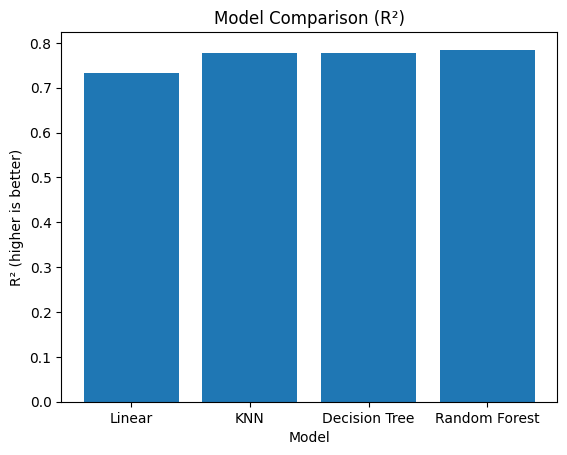

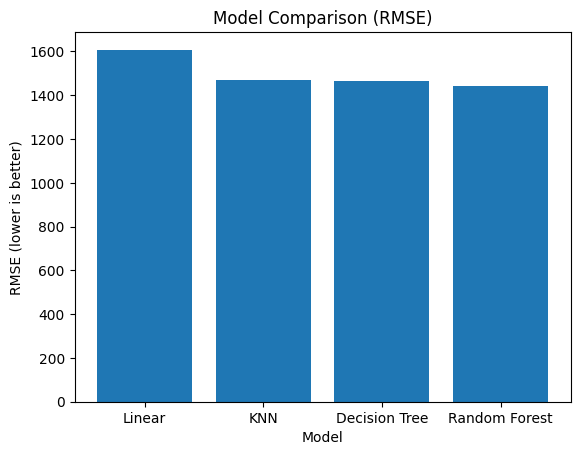

In [35]:
import matplotlib.pyplot as plt

models_r2 = ["Linear", "KNN", "Decision Tree", "Random Forest"]
models_rsme = ["Linear", "KNN", "Decision Tree", "Random Forest"]

# Replace these with your actual results
r2_scores = [val_r2_ols, best_r2_knn, best_r2_dt, best_r2_rf]
rmse_scores = [rmse_ols, best_rmse_knn, best_rmse_dt, best_rmse_rf]

# --- R2 plot ---
# which model explains the data better ?
plt.figure()
plt.bar(models_r2, r2_scores)
plt.title("Model Comparison (R²)")
plt.ylabel("R² (higher is better)")
plt.xlabel("Model")
plt.show()

# --- RMSE plot ---
# which model makes smaller errors ?
plt.figure()
plt.bar(models_rsme, rmse_scores)
plt.title("Model Comparison (RMSE)")
plt.ylabel("RMSE (lower is better)")
plt.xlabel("Model")
plt.show()

# Random Forest achieved the highest R² and lowest RMSE making it the best-performing model.

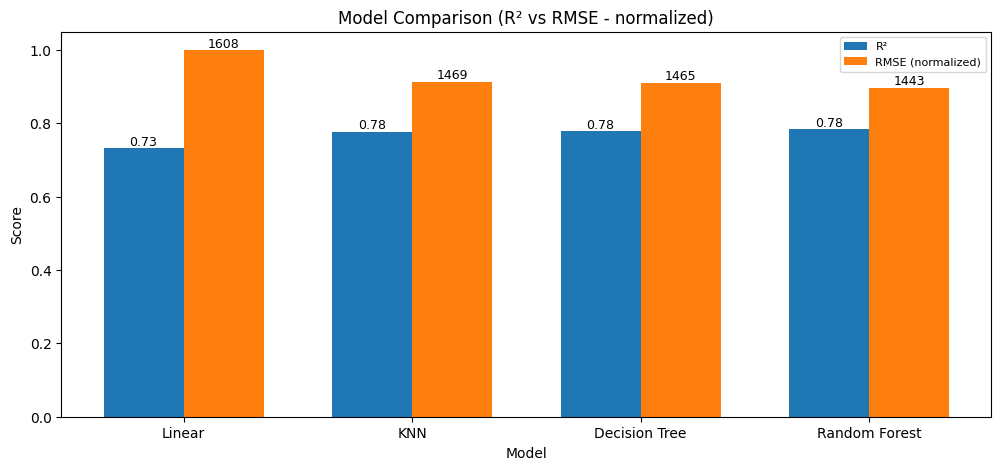

In [46]:
import numpy as np
import matplotlib.pyplot as plt

models = ['Linear','KNN', 'Decision Tree','Random Forest']
r2_scores = [val_r2_ols, best_r2_knn, best_r2_dt, best_r2_rf]
rmse_scores = [rmse_ols, best_rmse_knn, best_rmse_dt, best_rmse_rf]

x = np.arange(len(models))
width = 0.35
rmse_norm = np.array(rmse_scores) / max(rmse_scores)

plt.figure(figsize=(12,5))

bars1 = plt.bar(x - width/2, r2_scores, width, label='R²')
bars2 = plt.bar(x + width/2, rmse_norm, width, label='RMSE (normalized)')

for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{height:.2f}", ha='center', va='bottom', fontsize=9)

for i, bar in enumerate(bars2):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{rmse_scores[i]:.0f}", ha='center', va='bottom', fontsize=9)

plt.xticks(x, models)
plt.title("Model Comparison (R² vs RMSE - normalized)")
plt.xlabel("Model")
plt.ylabel("Score")
plt.legend(fontsize=8)
plt.show()


#### Conclusion:  
We evaluated four regression models using R² and RMSE. Linear Regression served as the baseline, while KNN, Decision Tree, and Random Forest were tuned using validation performance. Random Forest achieved the strongest overall results, indicating that ensemble tree methods captured the non-linear relationships in the data more effectively than the other models.

## 3. Output Summary

#### Test Data Predition
Predict sales data on the Test Data by adding it on the last column
#### Saving the results on the csv
Predict sales data on the Test Data by adding it on the last column

In [47]:
# ──────────────────────────────
# Final Random Forest on full training data
# ──────────────────────────────
rf_final = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# train on all available training data
rf_final.fit(X, y) #TRAIN DATA

# predict on the real dataset
sales_predictions = rf_final.predict(X_real) #WE PREDICT ON REAL DATA

# reload original REAL_DATA to keep all original columns (index, store_ID, date)
real_data_output = pd.read_csv('/content/drive/MyDrive/data/REAL_DATA.csv')
real_data_output['sales'] = sales_predictions

# if a store is closed in the real data, force sales to 0
real_data_output.loc[real_data_output['open'] == 0, 'sales'] = 0

# save final file
real_data_output.to_csv("REAL_DATA_with_sales_predictions.csv", index=False)

print("Prediction file created: REAL_DATA_with_sales_predictions.csv")
print(f"Rows: {len(real_data_output)}, Sales range: {real_data_output['sales'].min()} to {real_data_output['sales'].max()}")
real_data_output.head()

Prediction file created: REAL_DATA_with_sales_predictions.csv
Rows: 71205, Sales range: 0.0 to 36681.2890959596


,index,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,272371,415,7,01/03/2015,0,0,0,0,0,0.000000
1,558468,27,7,29/12/2013,0,0,0,0,0,0.000000
2,76950,404,3,19/03/2014,657,1,1,0,0,6736.838896
3,77556,683,2,29/01/2013,862,1,0,0,0,6649.365946
4,456344,920,3,19/03/2014,591,1,1,0,0,6207.244021


In [50]:
import os

#create a notebook to put there R2 and RMSE

# ── Save Results Summary ──────────────────────────────────────────────────────

# The best R2 and RMSE for the Random Forest model on the validation set
# were already calculated and stored in `best_r2_rf` and `best_rmse_rf`
final_r2   = best_r2_rf
final_rmse = best_rmse_rf

# Create the 'data' directory if it doesn't exist
os.makedirs('data', exist_ok=True)

with open('data/model_results.txt', 'w', encoding='utf-8') as f:
    f.write("=" * 40 + "\n")
    f.write("  RANDOM FOREST — Final Results\n")
    f.write("=" * 40 + "\n\n")
    f.write(f"  R²   : {final_r2:.4f}  ({final_r2:.2%})\n")
    f.write(f"  RMSE : {final_rmse:.4f}\n") # Corrected from R² to RMSE and removed percentage formatting
f.close()